In [33]:
# ============================================================
# 1. 离散序列数据生成（正序/倒序/无序 三类）
# ============================================================
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

vocab_size = 100
embed_dim = 32
state_dim = 64
min_len = 5
max_len = 48
lr = 1e-4

def generate_one_sequence(min_len=10, max_len=20, max_val=19):
    """
    生成单条离散序列及其标签
    标签0：严格递增（正序）
    标签1：严格递减（倒序）
    标签2：非单调（无序）
    序列长度：[min_len, max_len] 随机
    元素取值：0 ~ max_val 整数
    """
    seq_len = random.randint(min_len, max_len)
    label = random.randint(0, 2)

    if label == 0:  # 正序：严格递增
        nums = random.sample(range(max_val + 1), seq_len)
        nums.sort()
    elif label == 1:  # 倒序：严格递减
        nums = random.sample(range(max_val + 1), seq_len)
        nums.sort(reverse=True)
    else:  # 无序：确保非单调
        while True:
            nums = random.choices(range(max_val + 1), k=seq_len)
            is_increasing = all(nums[i] < nums[i + 1] for i in range(len(nums) - 1))
            is_decreasing = all(nums[i] > nums[i + 1] for i in range(len(nums) - 1))
            if not is_increasing and not is_decreasing:
                break

    return nums, label


# 生成训练集（2000条样本，三类均衡分布）
train_data = []
for _ in range(3000):
    seq, label = generate_one_sequence(max_val=vocab_size-1, min_len=min_len, max_len=max_len)
    train_data.append((seq, label))

val_data = []
for _ in range(200):
    seq, label = generate_one_sequence(max_val=vocab_size-1, min_len=min_len, max_len=max_len)
    val_data.append((seq, label))

# 生成测试集（20条，用于后续打印验证）
test_data = []
for _ in range(20):
    seq, label = generate_one_sequence(max_val=vocab_size-1, min_len=min_len, max_len=max_len)
    test_data.append((seq, label))

label_name = {0: "正序", 1: "倒序", 2: "无序"}
print(f"训练集数量: {len(train_data)}, 测试集数量: {len(test_data)}")

训练集数量: 3000, 测试集数量: 20


In [34]:
# ============================================================
# 2. SSM 离散分类模型（嵌入层 + 基础SSM + 分类头）
# ============================================================
class SimpleSSM(nn.Module):
    """
    与你现有结构完全一致的标准线性状态空间模型
    x_{k+1} = A @ x_k + B @ u_k
    y_{k+1} = C @ x_{k+1} + D @ u_k
    """

    def __init__(self, state_dim=64, input_dim=32, output_dim=32):
        super().__init__()
        self.state_dim = state_dim
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.A = nn.Parameter(torch.eye(state_dim) * 0.98 + torch.randn(state_dim, state_dim) * 0.01)
        self.B = nn.Parameter(torch.randn(state_dim, input_dim) * 0.1)
        self.C = nn.Parameter(torch.randn(output_dim, state_dim) * 0.1)
        self.D = nn.Parameter(torch.zeros(output_dim, input_dim))

        with torch.no_grad():
            spec_radius = torch.linalg.matrix_norm(self.A, ord=2)
            self.A.data = self.A / (spec_radius + 1e-6) * 0.98

    def step(self, x_prev, u):
        x_next = self.A @ x_prev + self.B @ u
        y = self.C @ x_next + self.D @ u
        return x_next, y

    def forward_sequence(self, u_seq, x0=None):
        T = u_seq.shape[0]
        if x0 is None:
            x = torch.zeros(self.state_dim, 1, device=u_seq.device)
        else:
            x = x0

        outputs = []
        for t in range(T):
            u_t = u_seq[t].reshape(-1, 1)
            x, y_t = self.step(x, u_t)
            outputs.append(y_t.squeeze(-1))

        outputs = torch.stack(outputs, dim=0)
        return outputs, x  # 返回所有输出 + 最终状态


class SSMClassifier(nn.Module):
    """离散序列分类器：嵌入层 + SSM + 分类头"""
    def __init__(self, vocab_size=20, embed_dim=32, state_dim=64, num_classes=3):
        super().__init__()
        # 离散索引转特征向量
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # 核心SSM模块
        self.ssm = SimpleSSM(state_dim=state_dim, input_dim=embed_dim, output_dim=embed_dim)
        # 分类头：用最终状态做分类
        self.classifier = nn.Linear(state_dim, num_classes)

    def forward(self, seq_indices):
        """
        seq_indices: 1D 整数张量，形状 (seq_len,)
        返回: 分类logits，形状 (num_classes,)
        """
        # 1. 离散索引嵌入
        x_emb = self.embedding(seq_indices)  # (seq_len, embed_dim)
        # 2. SSM 处理整个序列，取最终状态
        _, final_state = self.ssm.forward_sequence(x_emb)  # (state_dim, 1)
        # 3. 最终状态过分类头
        logits = self.classifier(final_state.squeeze(-1))  # (num_classes,)
        return logits



In [35]:
# ============================================================
# 3. 模型训练
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SSMClassifier(vocab_size=vocab_size, embed_dim=embed_dim, state_dim=state_dim, num_classes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

epochs = 50
x_0 = []
loss_list_0 = []
acc_list_0 = []
for epoch in range(epochs):
    model.train()
    random.shuffle(train_data)
    total_loss = 0.0
    for seq, label in train_data:
        seq_tensor = torch.LongTensor(seq).to(device)
        label_tensor = torch.LongTensor([label]).to(device).squeeze()

        optimizer.zero_grad()
        logits = model(seq_tensor)
        loss = criterion(logits.unsqueeze(0), label_tensor.unsqueeze(0))
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for seq, label in val_data:
            seq_tensor = torch.LongTensor(seq).to(device)
            label_tensor = torch.LongTensor([label]).to(device).squeeze()

            logits = model(seq_tensor)
            loss = criterion(logits.unsqueeze(0), label_tensor.unsqueeze(0))
            val_loss += loss

            pred = logits.argmax().item()
            if pred == label:
                correct += 1

    train_loss = total_loss / len(train_data)
    val_loss = val_loss / len(val_data)
    val_acc = correct / len(val_data)
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {train_loss:.4f}, Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    x_0.append(epoch + 1)
    loss_list_0.append(train_loss)
    acc_list_0.append(val_acc)

Epoch 1/50, Loss: 1.8621, Loss: 1.5896, Val Acc: 0.6800
Epoch 2/50, Loss: 3.0460, Loss: 2.5458, Val Acc: 0.7650
Epoch 3/50, Loss: 3.7498, Loss: 2.2689, Val Acc: 0.7850
Epoch 4/50, Loss: 3.9088, Loss: 3.3141, Val Acc: 0.8100
Epoch 5/50, Loss: 6.4684, Loss: 1.8270, Val Acc: 0.8450
Epoch 6/50, Loss: 6.3602, Loss: 4.0067, Val Acc: 0.8050
Epoch 7/50, Loss: 6.4208, Loss: 16.6733, Val Acc: 0.7950
Epoch 8/50, Loss: 8.5248, Loss: 1.0906, Val Acc: 0.8600
Epoch 9/50, Loss: 6.3197, Loss: 1.3995, Val Acc: 0.8600
Epoch 10/50, Loss: 5.2933, Loss: 1.5957, Val Acc: 0.8650
Epoch 11/50, Loss: 6.3432, Loss: 5.2105, Val Acc: 0.8350
Epoch 12/50, Loss: 6.5006, Loss: 1.7349, Val Acc: 0.8600
Epoch 13/50, Loss: 5.9522, Loss: 6.5227, Val Acc: 0.8500
Epoch 14/50, Loss: 6.7872, Loss: 1.5920, Val Acc: 0.8900
Epoch 15/50, Loss: 6.2378, Loss: 1.3609, Val Acc: 0.8850
Epoch 16/50, Loss: 6.4456, Loss: 2.1025, Val Acc: 0.8900
Epoch 17/50, Loss: 5.7674, Loss: 1.0560, Val Acc: 0.8950
Epoch 18/50, Loss: 6.2845, Loss: 1.2709

In [36]:
# ============================================================
# 4. 推理测试：直接打印结果
# ============================================================
model.eval()
correct_count = 0

print("=" * 70)
print(f"{'序号':<4} {'真实类型':<12} {'预测类型':<12} {'结果':<6} 序列预览")
print("-" * 70)

with torch.no_grad():
    for idx, (seq, label) in enumerate(test_data):
        seq_tensor = torch.LongTensor(seq).to(device)
        logits = model(seq_tensor)
        pred = logits.argmax().item()

        is_correct = pred == label
        correct_count += int(is_correct)
        result = "正确" if is_correct else "错误"

        # 序列太长只显示前10个加省略号
        seq_preview = str(seq[:10]).rstrip("]") + ", ...]" if len(seq) > 10 else str(seq)

        print(f"{idx + 1:<4} {label_name[label]:<12} {label_name[pred]:<12} {result:<6} {seq_preview}")

print("=" * 70)
print(f"测试集总准确率: {correct_count}/{len(test_data)} = {correct_count / len(test_data):.4f}")

序号   真实类型         预测类型         结果     序列预览
----------------------------------------------------------------------
1    无序           无序           正确     [85, 86, 0, 73, 26, 65, 71, 85, 9, 22, ...]
2    正序           正序           正确     [0, 1, 8, 9, 10, 11, 17, 19, 20, 21, ...]
3    正序           正序           正确     [11, 13, 23, 57, 66, 68, 69, 70, 74, 81, ...]
4    倒序           倒序           正确     [99, 98, 95, 93, 90, 89, 88, 87, 81, 79, ...]
5    正序           正序           正确     [0, 1, 2, 3, 6, 17, 20, 24, 25, 26, ...]
6    正序           正序           正确     [0, 1, 3, 4, 6, 10, 22, 26, 28, 33, ...]
7    正序           正序           正确     [4, 5, 6, 7, 10, 11, 12, 21, 22, 25, ...]
8    正序           无序           错误     [3, 13, 19, 22, 27, 40, 43, 48, 49, 54, ...]
9    倒序           倒序           正确     [98, 95, 94, 93, 90, 85, 83, 82, 80, 78, ...]
10   无序           无序           正确     [28, 1, 32, 78, 40, 19, 58, 28, 66, 82, ...]
11   倒序           倒序           正确     [98, 86, 79, 78, 60, 56, 45, 2

---

## 应用零阶保持的模型

In [37]:
# ============================================================
# 2. SSM 离散分类模型（零阶保持 ZOH 离散化版本）
# ============================================================
class SimpleSSM(nn.Module):
    """
    基于零阶保持(ZOH)离散化的线性状态空间模型
    连续系统：dx/dt = A_cont · x + B_cont · u
    零阶保持离散化后：
    x_{k+1} = A_d · x_k + B_d · u_k
    y_{k+1} = C · x_{k+1} + D · u_k

    其中 A_d, B_d 由连续参数通过矩阵指数计算得到
    """

    def __init__(self, state_dim=64, input_dim=32, output_dim=32, dt=1.0):
        super().__init__()
        self.state_dim = state_dim
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.dt = dt  # 离散时间步长，序列任务默认单位步长1.0

        # ========== 连续域可学习参数 ==========
        # A_cont：连续状态转移矩阵，初始化为负对角占优，保证连续系统稳定（特征值实部<0）
        self.A_log = nn.Parameter(torch.eye(state_dim) * 0.0 + torch.randn(state_dim, state_dim) * 0.01)
        # B_cont：连续输入矩阵
        self.B_cont = nn.Parameter(torch.randn(state_dim, input_dim) * 0.1)
        # C、D与离散系统直接对应，无需离散化
        self.C = nn.Parameter(torch.randn(output_dim, state_dim) * 0.1)
        self.D = nn.Parameter(torch.zeros(output_dim, input_dim))

        # 初始化校准：保证初始连续系统稳定
        with torch.no_grad():
            # 强制初始A_cont为负对角为主，实部均为负
            self.A_log.data = torch.abs(
                torch.diag(torch.ones(state_dim)) * 0.5 + torch.randn(state_dim, state_dim) * 0.01)

    def _zoh_discretize(self):
        """
        零阶保持离散化：从连续参数计算离散转移矩阵 A_d, B_d
        使用增广矩阵指数法，避免矩阵求逆，数值稳定性更好
        """
        # 构造连续A矩阵：A_cont = -exp(A_log)，保证特征值实部均为负，系统稳定
        A_cont = -torch.exp(self.A_log)  # [state_dim, state_dim]

        # 构建增广矩阵 M = [[A_cont*dt, B_cont*dt], [0, 0]]
        # 对M做矩阵指数后，左上角为A_d，右上角为B_d
        M = torch.zeros(self.state_dim + self.input_dim, self.state_dim + self.input_dim, device=A_cont.device)
        M[:self.state_dim, :self.state_dim] = A_cont * self.dt
        M[:self.state_dim, self.state_dim:] = self.B_cont * self.dt

        # 矩阵指数运算，完成ZOH离散化
        M_exp = torch.linalg.matrix_exp(M)

        A_d = M_exp[:self.state_dim, :self.state_dim]  # 离散状态转移矩阵
        B_d = M_exp[:self.state_dim, self.state_dim:]  # 离散输入矩阵
        return A_d, B_d

    def step(self, x_prev, u, A_d, B_d):
        """单步状态更新与预测，使用离散化后的矩阵"""
        x_next = A_d @ x_prev + B_d @ u
        y = self.C @ x_next + self.D @ u
        return x_next, y

    def forward_sequence(self, u_seq, x0=None):
        """
        批量处理序列，先做ZOH离散化，再迭代计算
        u_seq: [T, input_dim]
        返回: 所有输出 + 最终状态
        """
        T = u_seq.shape[0]
        if x0 is None:
            x = torch.zeros(self.state_dim, 1, device=u_seq.device)
        else:
            x = x0

        # 单次前向只做一次离散化，整段序列共用同一组离散矩阵
        A_d, B_d = self._zoh_discretize()

        outputs = []
        for t in range(T):
            u_t = u_seq[t].reshape(-1, 1)
            x, y_t = self.step(x, u_t, A_d, B_d)
            outputs.append(y_t.squeeze(-1))

        outputs = torch.stack(outputs, dim=0)
        return outputs, x  # 返回所有输出 + 最终状态


class SSMClassifier(nn.Module):
    """离散序列分类器：嵌入层 + ZOH-SSM + 分类头（接口与原版本完全一致）"""

    def __init__(self, vocab_size=20, embed_dim=32, state_dim=64, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.ssm = SimpleSSM(state_dim=state_dim, input_dim=embed_dim, output_dim=embed_dim)
        self.classifier = nn.Linear(state_dim, num_classes)

    def forward(self, seq_indices):
        """
        seq_indices: 1D 整数张量，形状 (seq_len,)
        返回: 分类logits，形状 (num_classes,)
        """
        x_emb = self.embedding(seq_indices)  # (seq_len, embed_dim)
        _, final_state = self.ssm.forward_sequence(x_emb)  # (state_dim, 1)
        logits = self.classifier(final_state.squeeze(-1))  # (num_classes,)
        return logits

In [38]:
# ============================================================
# 3. 模型训练
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SSMClassifier(vocab_size=vocab_size, embed_dim=embed_dim, state_dim=state_dim, num_classes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

x_1 = []
loss_list_1 = []
acc_list_1 = []
for epoch in range(epochs):
    model.train()
    random.shuffle(train_data)
    total_loss = 0.0
    for seq, label in train_data:
        seq_tensor = torch.LongTensor(seq).to(device)
        label_tensor = torch.LongTensor([label]).to(device).squeeze()

        optimizer.zero_grad()
        logits = model(seq_tensor)
        loss = criterion(logits.unsqueeze(0), label_tensor.unsqueeze(0))
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    model.eval()
    val_loss = 0.0
    correct = 0
    with torch.no_grad():
        for seq, label in val_data:
            seq_tensor = torch.LongTensor(seq).to(device)
            label_tensor = torch.LongTensor([label]).to(device).squeeze()

            logits = model(seq_tensor)
            loss = criterion(logits.unsqueeze(0), label_tensor.unsqueeze(0))
            val_loss += loss

            pred = logits.argmax().item()
            if pred == label:
                correct += 1

    train_loss = total_loss / len(train_data)
    val_loss = val_loss / len(val_data)
    val_acc = correct / len(val_data)
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {train_loss:.4f}, Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    x_1.append(epoch + 1)
    loss_list_1.append(train_loss)
    acc_list_1.append(val_acc)

Epoch 1/50, Loss: 0.8223, Loss: 0.6761, Val Acc: 0.7000
Epoch 2/50, Loss: 0.7042, Loss: 0.6366, Val Acc: 0.7850
Epoch 3/50, Loss: 0.6840, Loss: 0.5318, Val Acc: 0.8550
Epoch 4/50, Loss: 0.5770, Loss: 0.4703, Val Acc: 0.8600
Epoch 5/50, Loss: 0.5246, Loss: 0.4882, Val Acc: 0.8700
Epoch 6/50, Loss: 0.4995, Loss: 0.5212, Val Acc: 0.8700
Epoch 7/50, Loss: 0.4669, Loss: 0.4780, Val Acc: 0.8900
Epoch 8/50, Loss: 0.4402, Loss: 0.5182, Val Acc: 0.8750
Epoch 9/50, Loss: 0.4223, Loss: 0.5162, Val Acc: 0.8800
Epoch 10/50, Loss: 0.4269, Loss: 0.4688, Val Acc: 0.8800
Epoch 11/50, Loss: 0.3999, Loss: 0.5915, Val Acc: 0.8550
Epoch 12/50, Loss: 0.3828, Loss: 0.4948, Val Acc: 0.8700
Epoch 13/50, Loss: 0.3695, Loss: 0.4651, Val Acc: 0.8900
Epoch 14/50, Loss: 0.3514, Loss: 0.4606, Val Acc: 0.8950
Epoch 15/50, Loss: 0.3876, Loss: 0.3803, Val Acc: 0.8850
Epoch 16/50, Loss: 0.4364, Loss: 0.3473, Val Acc: 0.9250
Epoch 17/50, Loss: 0.5350, Loss: 0.4708, Val Acc: 0.9050
Epoch 18/50, Loss: 0.5733, Loss: 0.8632,

In [39]:
# ============================================================
# 4. 推理测试：直接打印结果
# ============================================================
model.eval()
correct_count = 0

print("=" * 70)
print(f"{'序号':<4} {'真实类型':<12} {'预测类型':<12} {'结果':<6} 序列预览")
print("-" * 70)

with torch.no_grad():
    for idx, (seq, label) in enumerate(test_data):
        seq_tensor = torch.LongTensor(seq).to(device)
        logits = model(seq_tensor)
        pred = logits.argmax().item()

        is_correct = pred == label
        correct_count += int(is_correct)
        result = "正确" if is_correct else "错误"

        # 序列太长只显示前10个加省略号
        seq_preview = str(seq[:10]).rstrip("]") + ", ...]" if len(seq) > 10 else str(seq)

        print(f"{idx + 1:<4} {label_name[label]:<12} {label_name[pred]:<12} {result:<6} {seq_preview}")

print("=" * 70)
print(f"测试集总准确率: {correct_count}/{len(test_data)} = {correct_count / len(test_data):.4f}")

序号   真实类型         预测类型         结果     序列预览
----------------------------------------------------------------------
1    无序           无序           正确     [85, 86, 0, 73, 26, 65, 71, 85, 9, 22, ...]
2    正序           正序           正确     [0, 1, 8, 9, 10, 11, 17, 19, 20, 21, ...]
3    正序           正序           正确     [11, 13, 23, 57, 66, 68, 69, 70, 74, 81, ...]
4    倒序           倒序           正确     [99, 98, 95, 93, 90, 89, 88, 87, 81, 79, ...]
5    正序           正序           正确     [0, 1, 2, 3, 6, 17, 20, 24, 25, 26, ...]
6    正序           正序           正确     [0, 1, 3, 4, 6, 10, 22, 26, 28, 33, ...]
7    正序           正序           正确     [4, 5, 6, 7, 10, 11, 12, 21, 22, 25, ...]
8    正序           正序           正确     [3, 13, 19, 22, 27, 40, 43, 48, 49, 54, ...]
9    倒序           倒序           正确     [98, 95, 94, 93, 90, 85, 83, 82, 80, 78, ...]
10   无序           无序           正确     [28, 1, 32, 78, 40, 19, 58, 28, 66, 82, ...]
11   倒序           倒序           正确     [98, 86, 79, 78, 60, 56, 45, 2

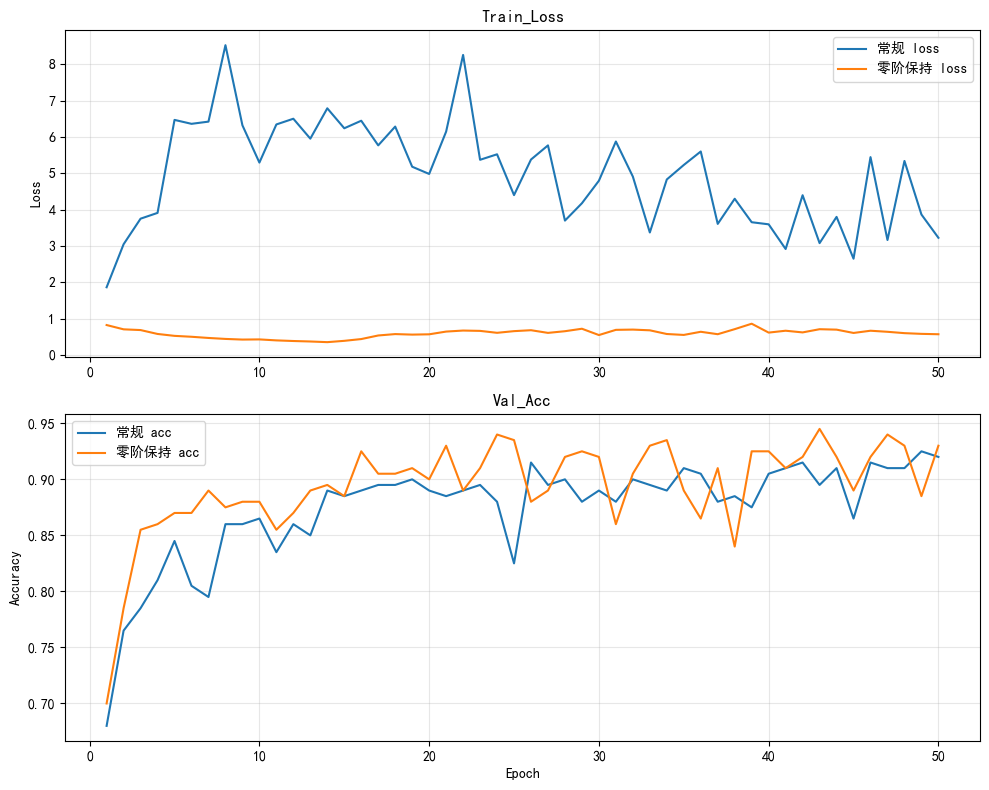

In [40]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False    # 负号正常显示

# 创建2行1列子图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# 子图1：损失曲线
ax1.plot(x_0, loss_list_0, label='常规 loss', color='#1f77b4')
ax1.plot(x_1, loss_list_1, label='零阶保持 loss', color='#ff7f0e')
ax1.set_title('Train_Loss')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# 子图2：准确率曲线
ax2.plot(x_0, acc_list_0, label='常规 acc', color='#1f77b4')
ax2.plot(x_1, acc_list_1, label='零阶保持 acc', color='#ff7f0e')
ax2.set_title('Val_Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# 紧凑布局防止标题重叠
plt.tight_layout()
plt.show()

In [41]:
# torch.save(model.state_dict(), "model/24_SSM-时序离散分类.pth")